# Module 3 — Validation & Robustness
## Ohio Dental Clinic — Site Selection Analysis

**Purpose:** Robustness validation and supplementary analysis. Tests ranking stability across 5 weight scenarios. Validates normalization method independence (min-max vs. z-score). Computes Pearson correlations between all variables. Calculates market gap index (income-weighted demand per competitor). Generates Tableau-ready export files.

| | |
|---|---|
| **Input** | `master_dataset.csv`, `module2_scores.csv` |
| **Output** | 6 chart PNGs, `tableau_locations.csv`, `tableau_demographics.csv`, `tableau_competitors.csv` |
| **Key finding** | Lewis Center ranks #1 in 4 of 5 weight scenarios — rankings identical under min-max and z-score normalization |

In [1]:
# LIBRARIES
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

# PATHS 
DATA_PATH    = r"../outputs"
CLEANED_PATH = r"../data/cleaned"
OUTPUT_PATH  = r"../outputs"
CHARTS_PATH  = r"../charts/charts_m3"

os.makedirs(CHARTS_PATH, exist_ok=True)

# CHART STYLE 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

# CONSTANTS 
COLOR_MAP = {
    "Ontario":       "#0F2240",
    "Westerville":   "#0D8C7A",
    "Sawmill Rd":    "#E8A730",
    "Lewis Center":  "#C0392B",
    "Indianola Ave": "#5B5EA6",
    "Hamilton Rd":   "#2E86AB",
}
COLORS = list(COLOR_MAP.values())

print("Setup complete.")

Setup complete.


In [2]:
# LOAD ALL PRIOR OUTPUTS 
master = pd.read_csv(os.path.join(DATA_PATH, "master_dataset.csv"))
scores = pd.read_csv(os.path.join(DATA_PATH, "module2_scores.csv"))

# Clean up _x/_y suffixes if present from Module 1 internal merge
rename_map = {c: c.replace("_x", "") for c in master.columns if c.endswith("_x")}
master = master.rename(columns=rename_map)
master = master[[c for c in master.columns if not c.endswith("_y")]]

# Merge scores into master
df = master.merge(scores, on=["location_id", "location_name"], how="left")

print(f"Working table: {len(df)} rows x {len(df.columns)} columns")
print(f"Locations: {df['location_name'].tolist()}")

Working table: 6 rows x 43 columns
Locations: ['Ontario', 'Westerville', 'Sawmill Rd', 'Lewis Center', 'Indianola Ave', 'Hamilton Rd']


In [3]:
# NORMALIZATION FUNCTIONS 
def normalize(series, invert=False):
    """Min-max normalize a series to 0-100. Invert = lower raw = higher score."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([50.0] * len(series), index=series.index)
    norm = (series - mn) / (mx - mn) * 100
    return 100 - norm if invert else norm

def zscore_normalize(series, invert=False):
    """Normalize to z-scores then rescale to 0-100."""
    z = (series - series.mean()) / series.std()
    if invert:
        z = -z
    return normalize(z)

print("Helper functions defined.")

Helper functions defined.


In [4]:
# CORRELATION ANALYSIS 
# With only 6 locations we cannot run inferential statistics meaningfully.
# Pearson correlation is valid as an exploratory tool — it tells us which
# variables measure the same underlying construct (and can be dropped).
# Key question: are income and education redundant? If r > 0.90, keeping
# both adds noise rather than signal to the model.

corr_cols = {
    "total_population":  "Population",
    "median_income":     "Median Income",
    "pct_bachelor_plus": "Bachelor's+%",
    "medicaid_pct":      "Medicaid%",
    "total_15min":       "Competitors (15min)",
    "total_30min":       "Competitors (30min)",
    "general_15min":     "Gen. Dentists (15min)",
}

corr_df = df[[c for c in corr_cols.keys() if c in df.columns]].copy()
corr_df.columns = [corr_cols[c] for c in corr_df.columns]
corr_matrix = corr_df.corr(method="pearson").round(2)

print("PEARSON CORRELATION MATRIX")
print("=" * 65)
print(corr_matrix.to_string())

r_inc_edu = corr_matrix.loc["Median Income", "Bachelor's+%"]
r_15_30   = corr_matrix.loc["Competitors (15min)", "Competitors (30min)"]
r_tot_gen = corr_matrix.loc["Competitors (15min)", "Gen. Dentists (15min)"]

print("\nKey pairs:")
print(f"  Income vs Education:       r = {r_inc_edu:.2f}")
print(f"  Competitors 15 vs 30 min:  r = {r_15_30:.2f}")
print(f"  Total vs General Dentists: r = {r_tot_gen:.2f}")

PEARSON CORRELATION MATRIX
                       Population  Median Income  Bachelor's+%  Medicaid%  Competitors (15min)  Competitors (30min)  Gen. Dentists (15min)
Population                   1.00           0.83          0.99      -0.97                 0.91                 1.00                   0.91
Median Income                0.83           1.00          0.89      -0.87                 0.62                 0.85                   0.60
Bachelor's+%                 0.99           0.89          1.00      -0.96                 0.85                 1.00                   0.86
Medicaid%                   -0.97          -0.87         -0.96       1.00                -0.92                -0.97                  -0.91
Competitors (15min)          0.91           0.62          0.85      -0.92                 1.00                 0.89                   1.00
Competitors (30min)          1.00           0.85          1.00      -0.97                 0.89                 1.00                   0.90


In [5]:
# SENSITIVITY ANALYSIS 
# Tests whether the ranking changes under different weight assumptions.
# If Lewis Center ranks #1 across most scenarios, the recommendation is robust.
# 5 scenarios:
#   Base:         Pop 30 | Inc 30 | Comp 25 | Med 15  (Module 2 weights)
#   Competition+: Pop 25 | Inc 25 | Comp 40 | Med 10
#   Income+:      Pop 20 | Inc 45 | Comp 25 | Med 10
#   Population+:  Pop 45 | Inc 25 | Comp 20 | Med 10
#   Equal:        Pop 25 | Inc 25 | Comp 25 | Med 25

# Pre-normalize all 4 dimensions
df["n_pop"]  = normalize(df["total_population"])
df["n_inc"]  = normalize(df["median_income"])
df["n_comp"] = normalize(df["total_15min"], invert=True)
df["n_med"]  = normalize(df["medicaid_pct"], invert=True)

scenarios = {
    "Base (30/30/25/15)":         (0.30, 0.30, 0.25, 0.15),
    "Competition+ (25/25/40/10)": (0.25, 0.25, 0.40, 0.10),
    "Income+ (20/45/25/10)":      (0.20, 0.45, 0.25, 0.10),
    "Population+ (45/25/20/10)":  (0.45, 0.25, 0.20, 0.10),
    "Equal (25/25/25/25)":        (0.25, 0.25, 0.25, 0.25),
}

sensitivity_rows = []
for scenario, (w_pop, w_inc, w_comp, w_med) in scenarios.items():
    df[f"score_{scenario}"] = (
        df["n_pop"]  * w_pop +
        df["n_inc"]  * w_inc +
        df["n_comp"] * w_comp +
        df["n_med"]  * w_med
    ).round(1)
    ranked = df.sort_values(f"score_{scenario}", ascending=False)
    for rank_pos, (_, row) in enumerate(ranked.iterrows(), 1):
        sensitivity_rows.append({
            "scenario": scenario,
            "location": row["location_name"],
            "score":    row[f"score_{scenario}"],
            "rank":     rank_pos,
        })

sens_df    = pd.DataFrame(sensitivity_rows)
pivot_rank = sens_df.pivot(index="location", columns="scenario", values="rank")
pivot_score = sens_df.pivot(index="location", columns="scenario", values="score")
top1_counts = sens_df[sens_df["rank"] == 1]["location"].value_counts()

print("SENSITIVITY ANALYSIS — RANKINGS BY SCENARIO")
print("=" * 75)
print(pivot_rank.to_string())
print("\nSCORES BY SCENARIO")
print(pivot_score.round(1).to_string())
print("\nTimes ranked #1 across all 5 scenarios:")
print(top1_counts.to_string())

sens_df.to_csv(os.path.join(OUTPUT_PATH, "module3_sensitivity.csv"), index=False)
print("\nSaved: module3_sensitivity.csv")

SENSITIVITY ANALYSIS — RANKINGS BY SCENARIO
scenario       Base (30/30/25/15)  Competition+ (25/25/40/10)  Equal (25/25/25/25)  Income+ (20/45/25/10)  Population+ (45/25/20/10)
location                                                                                                                            
Hamilton Rd                     4                           4                    4                      4                          4
Indianola Ave                   5                           5                    5                      5                          5
Lewis Center                    1                           1                    2                      1                          1
Ontario                         6                           6                    6                      6                          6
Sawmill Rd                      2                           2                    1                      2                          2
Westerville              

In [6]:
# MARKET GAP INDEX
# A more nuanced demand/supply metric than raw competitor counts.
# Income-weighted population / competitors — higher = more underserved.
# Weights a high-income population more heavily than a low-income one of equal size.

df["residents_per_dentist"] = df["total_population"] / df["total_15min"]
df["income_weighted_pop"]   = df["total_population"] * (df["median_income"] / df["median_income"].mean())
df["market_gap_index"]      = df["income_weighted_pop"] / df["total_15min"]
df["market_gap_normalized"] = normalize(df["market_gap_index"])

print("MARKET GAP INDEX (income-weighted population per competitor)")
print("=" * 60)
for _, row in df.sort_values("market_gap_normalized", ascending=False).iterrows():
    print(f"  {row['location_name']:<16}  "
          f"Residents/Dentist: {row['residents_per_dentist']:,.0f}  "
          f"Gap Index: {row['market_gap_index']:,.0f}  "
          f"Normalized: {row['market_gap_normalized']:.1f}")

MARKET GAP INDEX (income-weighted population per competitor)
  Lewis Center      Residents/Dentist: 2,029  Gap Index: 2,190  Normalized: 100.0
  Hamilton Rd       Residents/Dentist: 1,913  Gap Index: 1,910  Normalized: 71.6
  Sawmill Rd        Residents/Dentist: 1,548  Gap Index: 1,671  Normalized: 47.4
  Westerville       Residents/Dentist: 1,544  Gap Index: 1,630  Normalized: 43.3
  Ontario           Residents/Dentist: 1,843  Gap Index: 1,520  Normalized: 32.1
  Indianola Ave     Residents/Dentist: 1,250  Gap Index: 1,203  Normalized: 0.0


In [7]:
# Z-SCORE NORMALIZATION 
# Min-max is sensitive to outliers. Z-score is more robust.
# We compare both to confirm rankings are stable regardless of method.

df["z_pop"]  = zscore_normalize(df["total_population"])
df["z_inc"]  = zscore_normalize(df["median_income"])
df["z_comp"] = zscore_normalize(df["total_15min"], invert=True)
df["z_med"]  = zscore_normalize(df["medicaid_pct"], invert=True)

w = (0.30, 0.30, 0.25, 0.15)
df["zscore_opportunity"] = (
    df["z_pop"]  * w[0] +
    df["z_inc"]  * w[1] +
    df["z_comp"] * w[2] +
    df["z_med"]  * w[3]
).round(1)
df["zscore_rank"] = df["zscore_opportunity"].rank(ascending=False).astype(int)

print("Z-SCORE vs MIN-MAX SCORING COMPARISON")
print("=" * 60)
print(f"{'Location':<16} {'MinMax Score':>13} {'MinMax Rank':>12} "
      f"{'ZScore Score':>13} {'ZScore Rank':>12} {'Rank Diff':>10}")
print("-" * 60)
for _, row in df.sort_values("rank").iterrows():
    diff     = int(row["zscore_rank"]) - int(row["rank"])
    diff_str = f"+{diff}" if diff > 0 else str(diff)
    print(f"  {row['location_name']:<14} {row['opportunity_score']:>13.1f} "
          f"#{int(row['rank']):<11} {row['zscore_opportunity']:>13.1f} "
          f"#{int(row['zscore_rank']):<11} {diff_str:>10}")

Z-SCORE vs MIN-MAX SCORING COMPARISON
Location          MinMax Score  MinMax Rank  ZScore Score  ZScore Rank  Rank Diff
------------------------------------------------------------
  Lewis Center            81.0 #1                    81.0 #1                    0
  Sawmill Rd              79.4 #2                    79.4 #2                    0
  Westerville             74.2 #3                    74.2 #3                    0
  Hamilton Rd             69.8 #4                    69.8 #4                    0
  Indianola Ave           60.0 #5                    60.0 #5                    0
  Ontario                 25.0 #6                    25.0 #6                    0


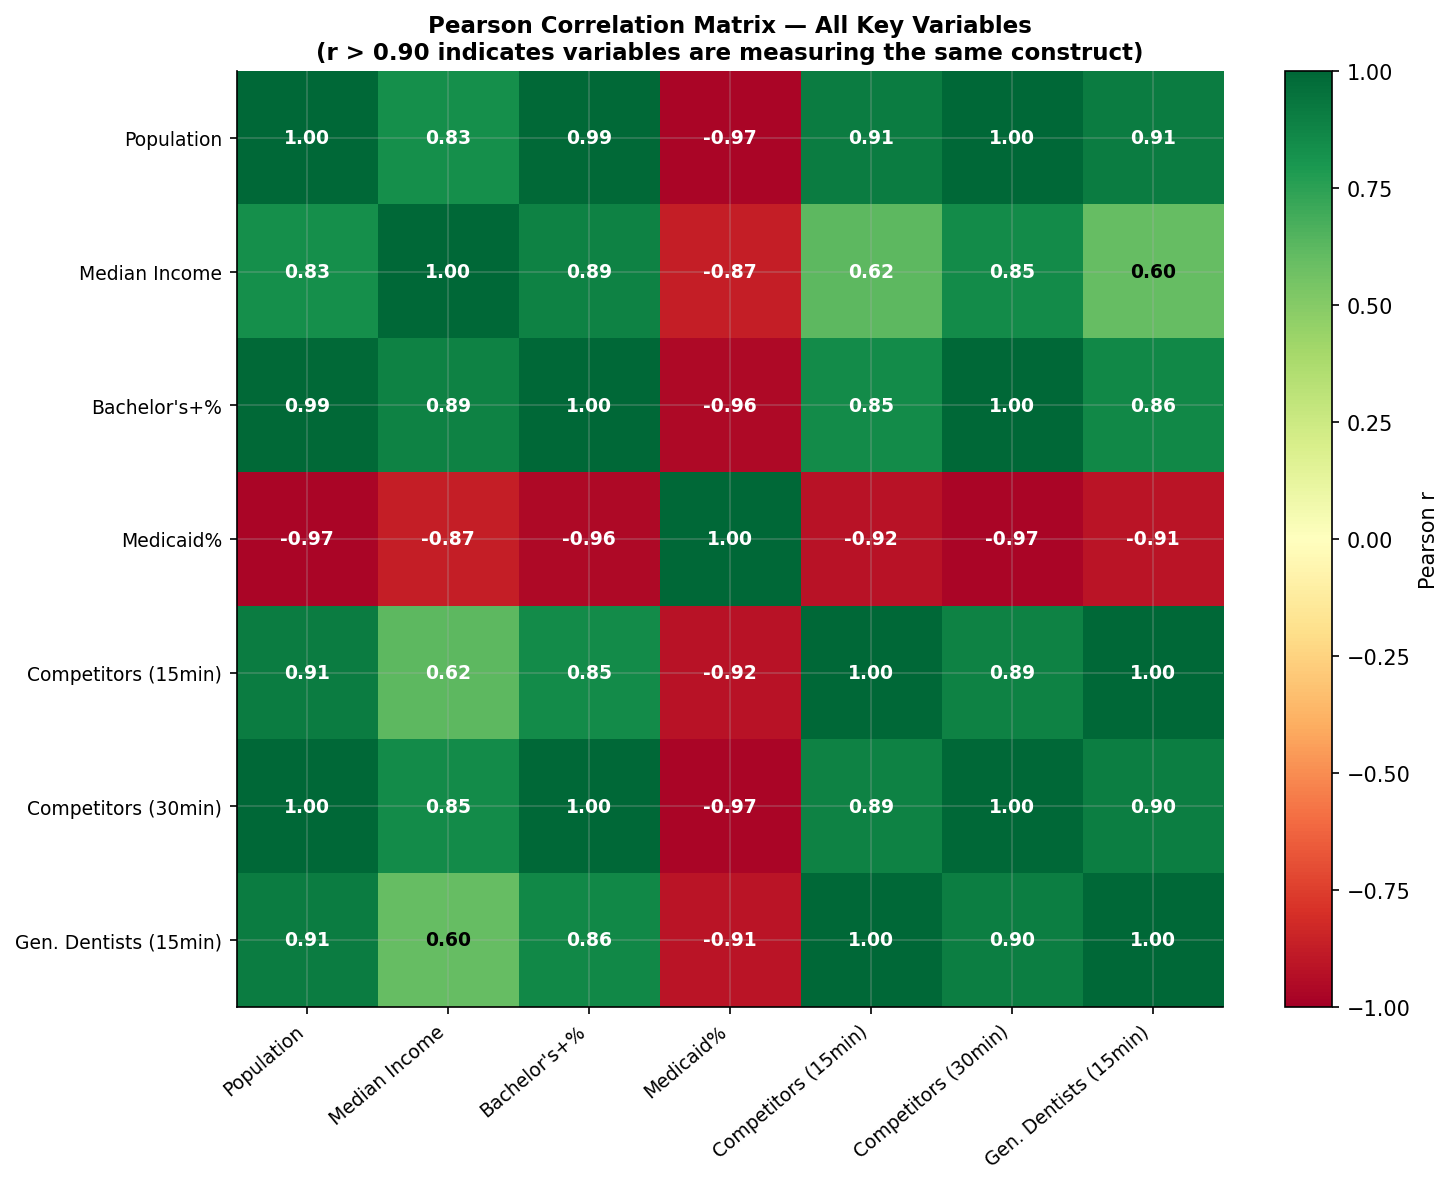

Chart 1 saved.


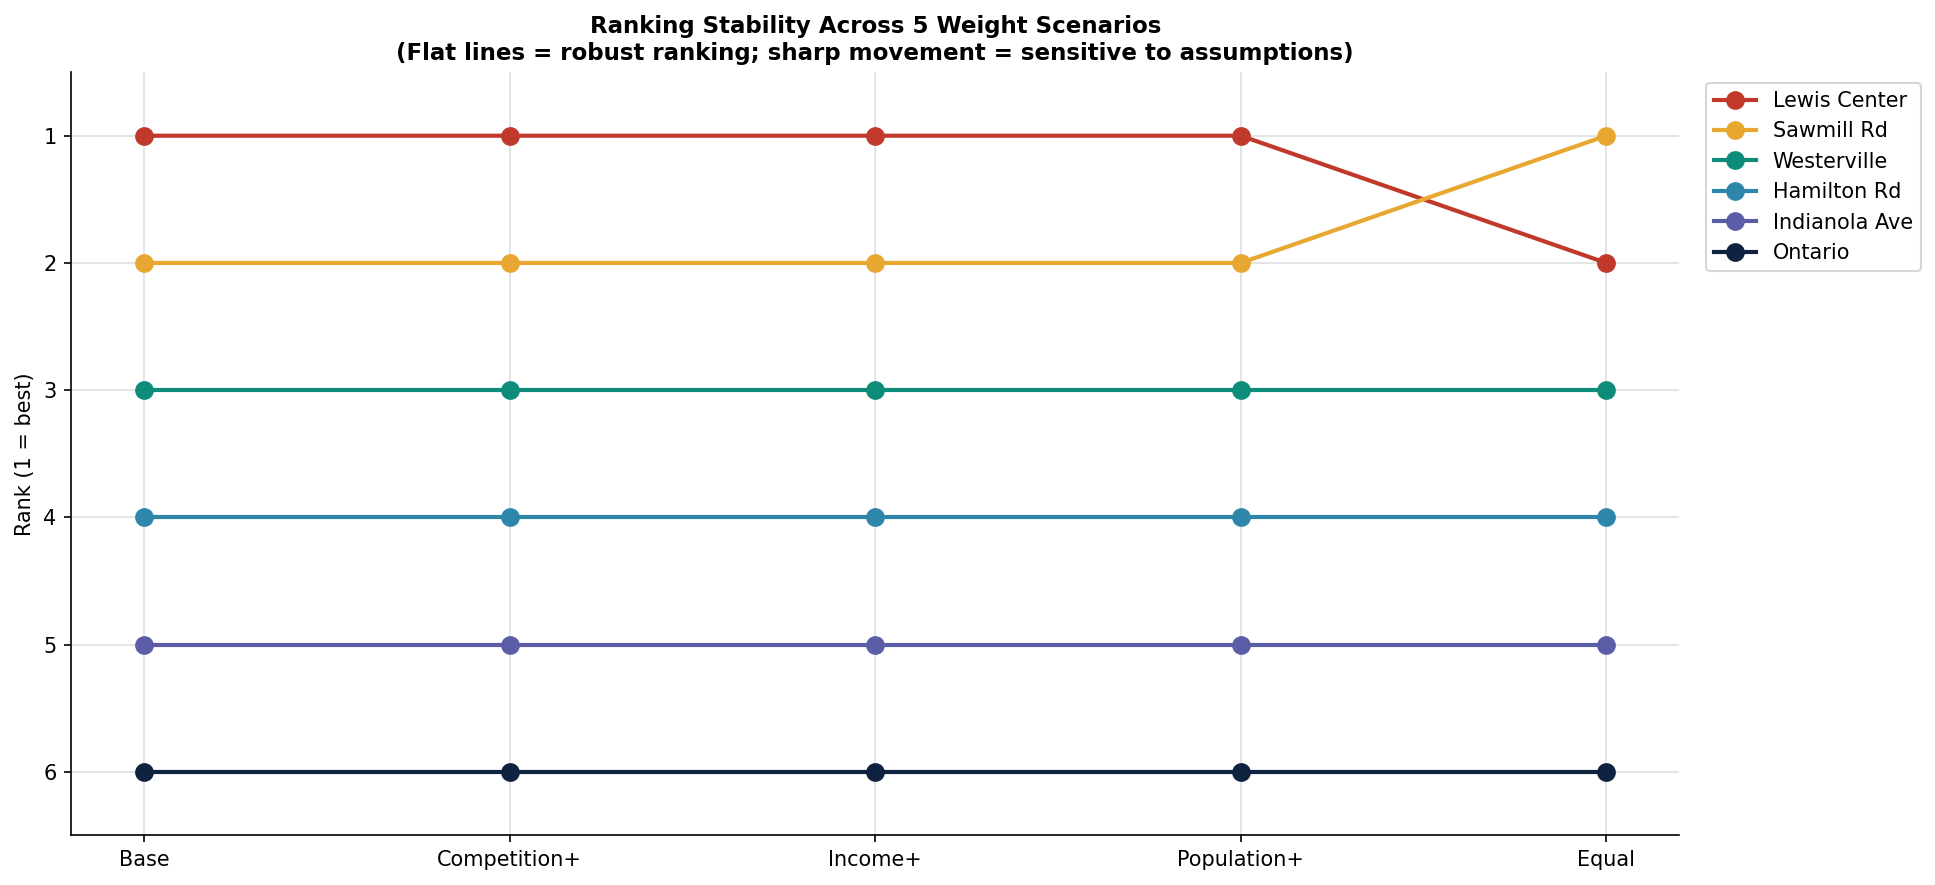

Chart 2 saved.


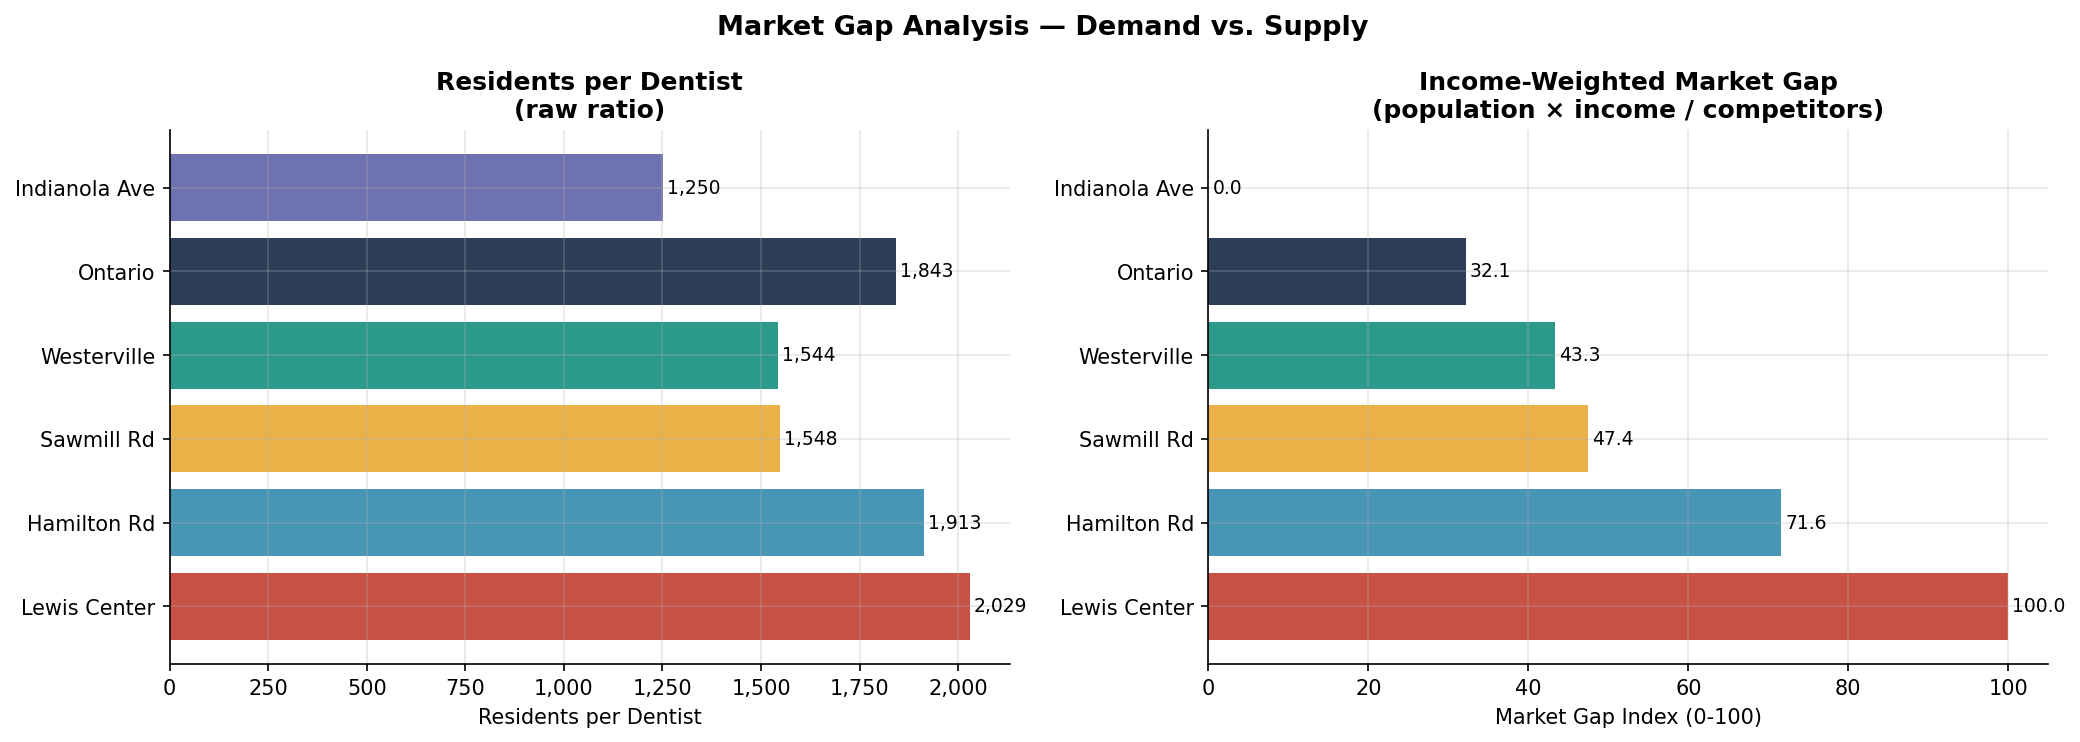

Chart 3 saved.


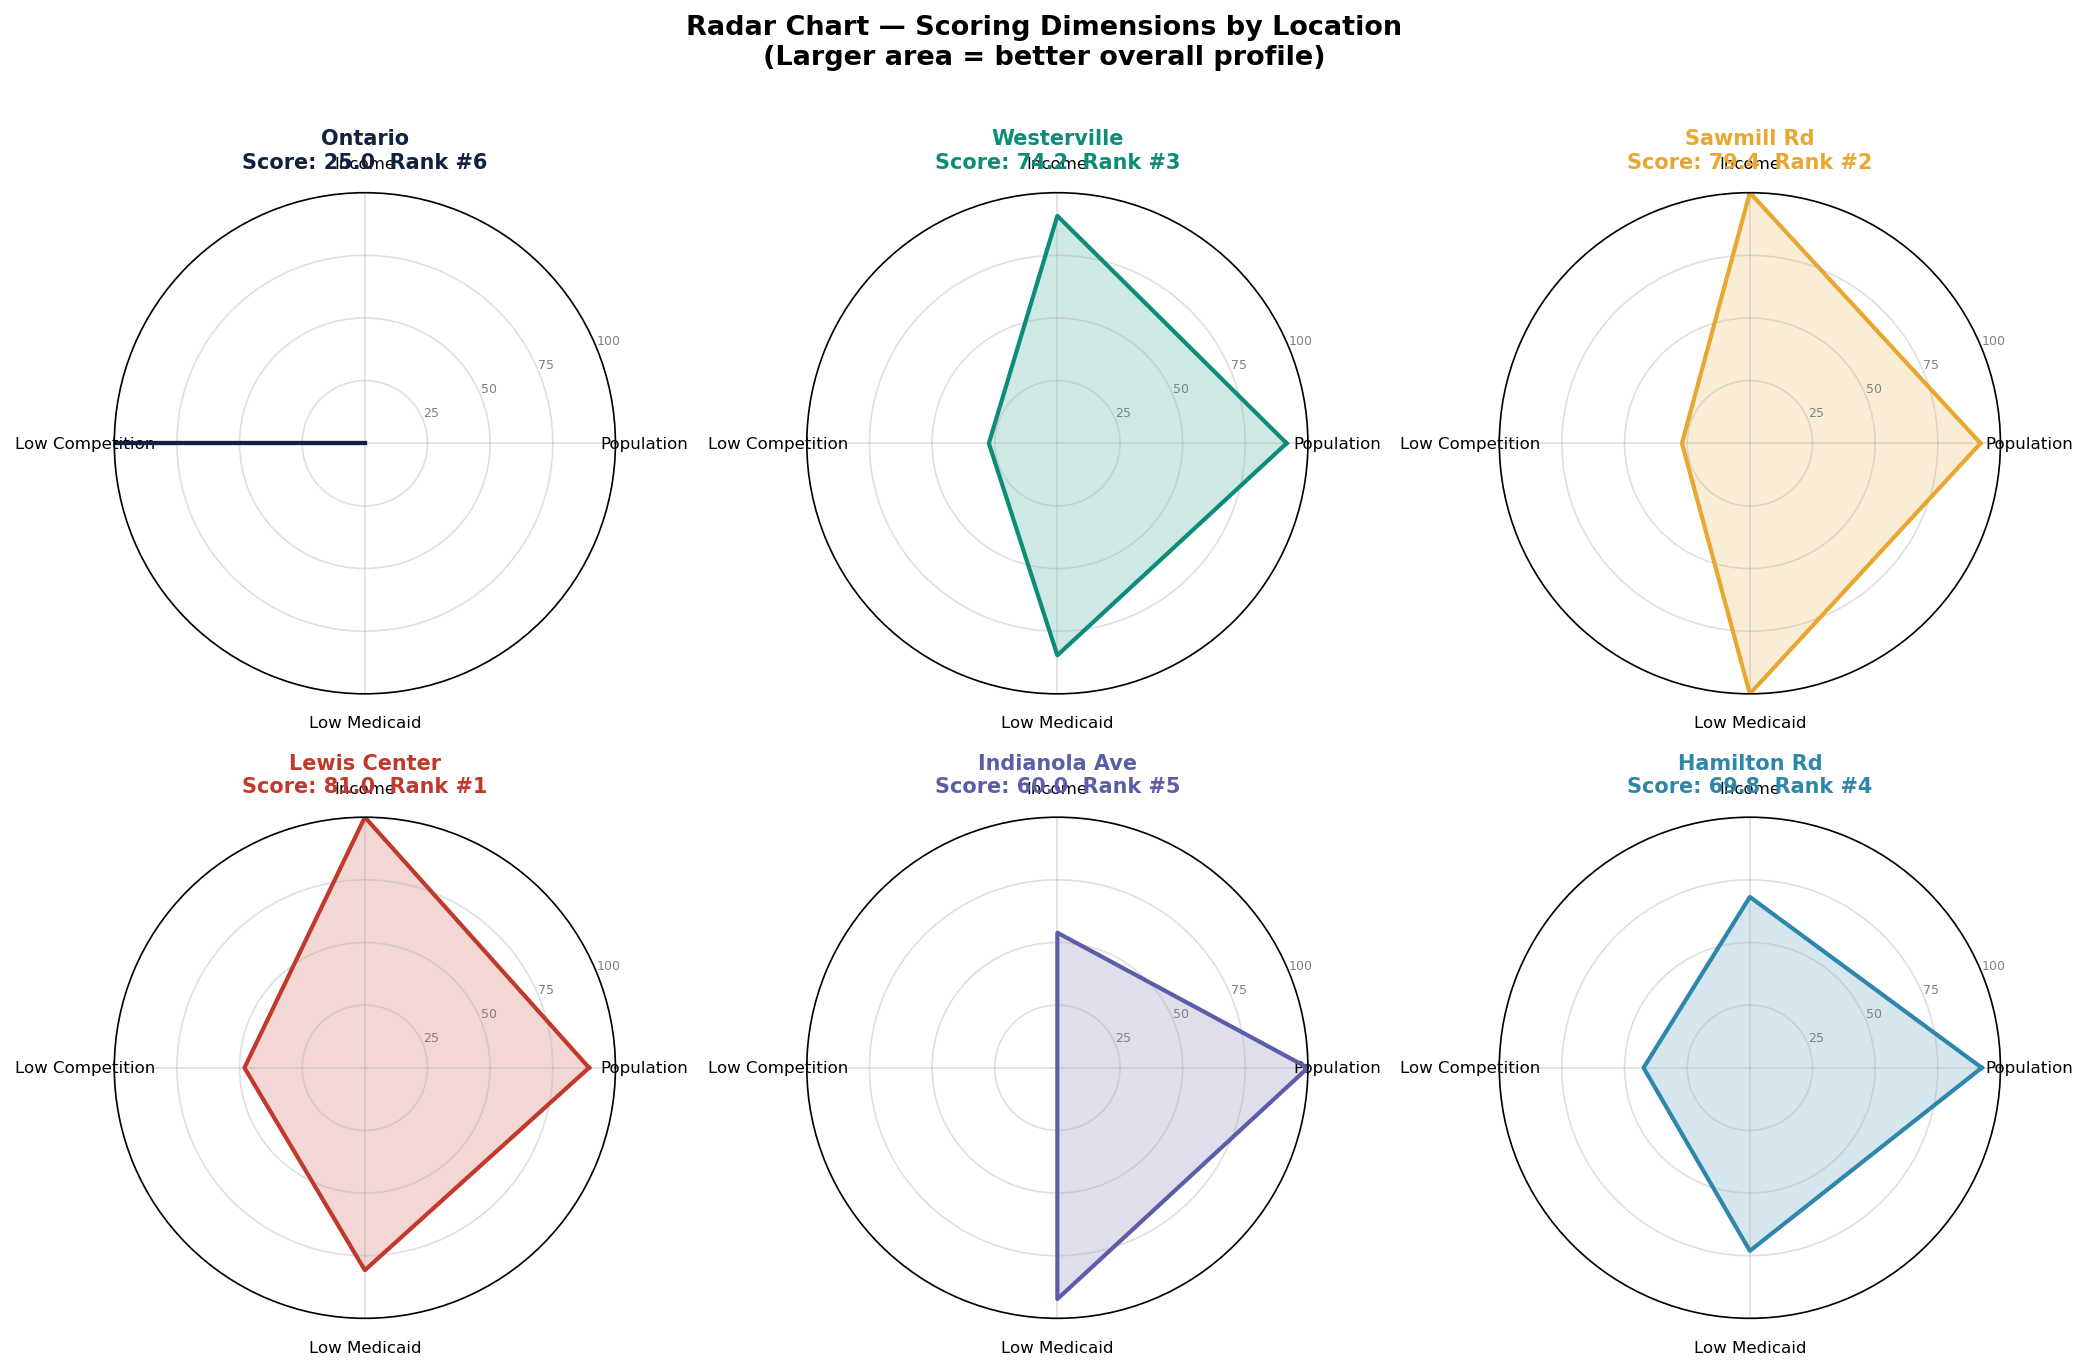

Chart 4 saved.


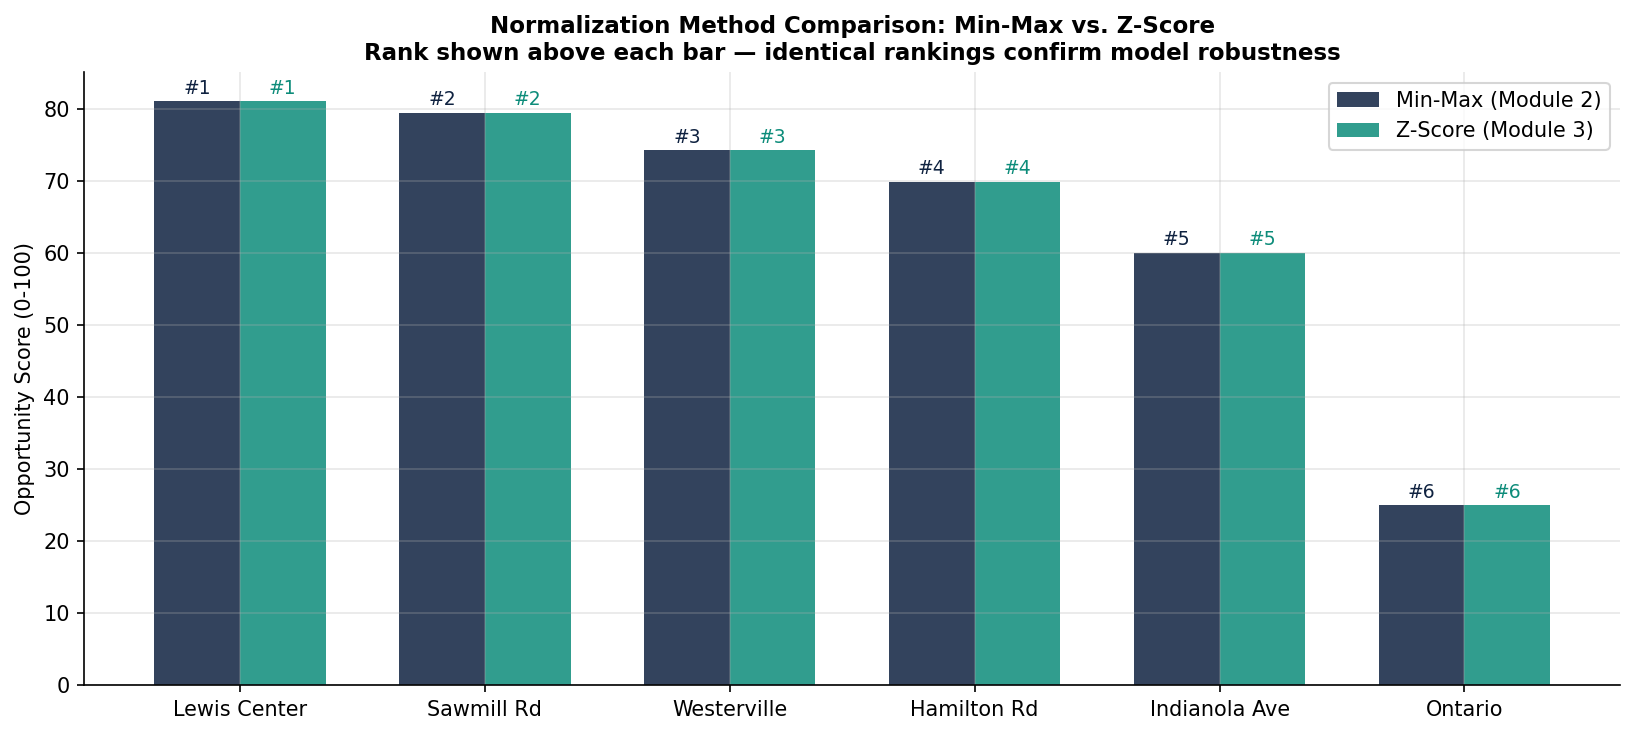

Chart 5 saved.


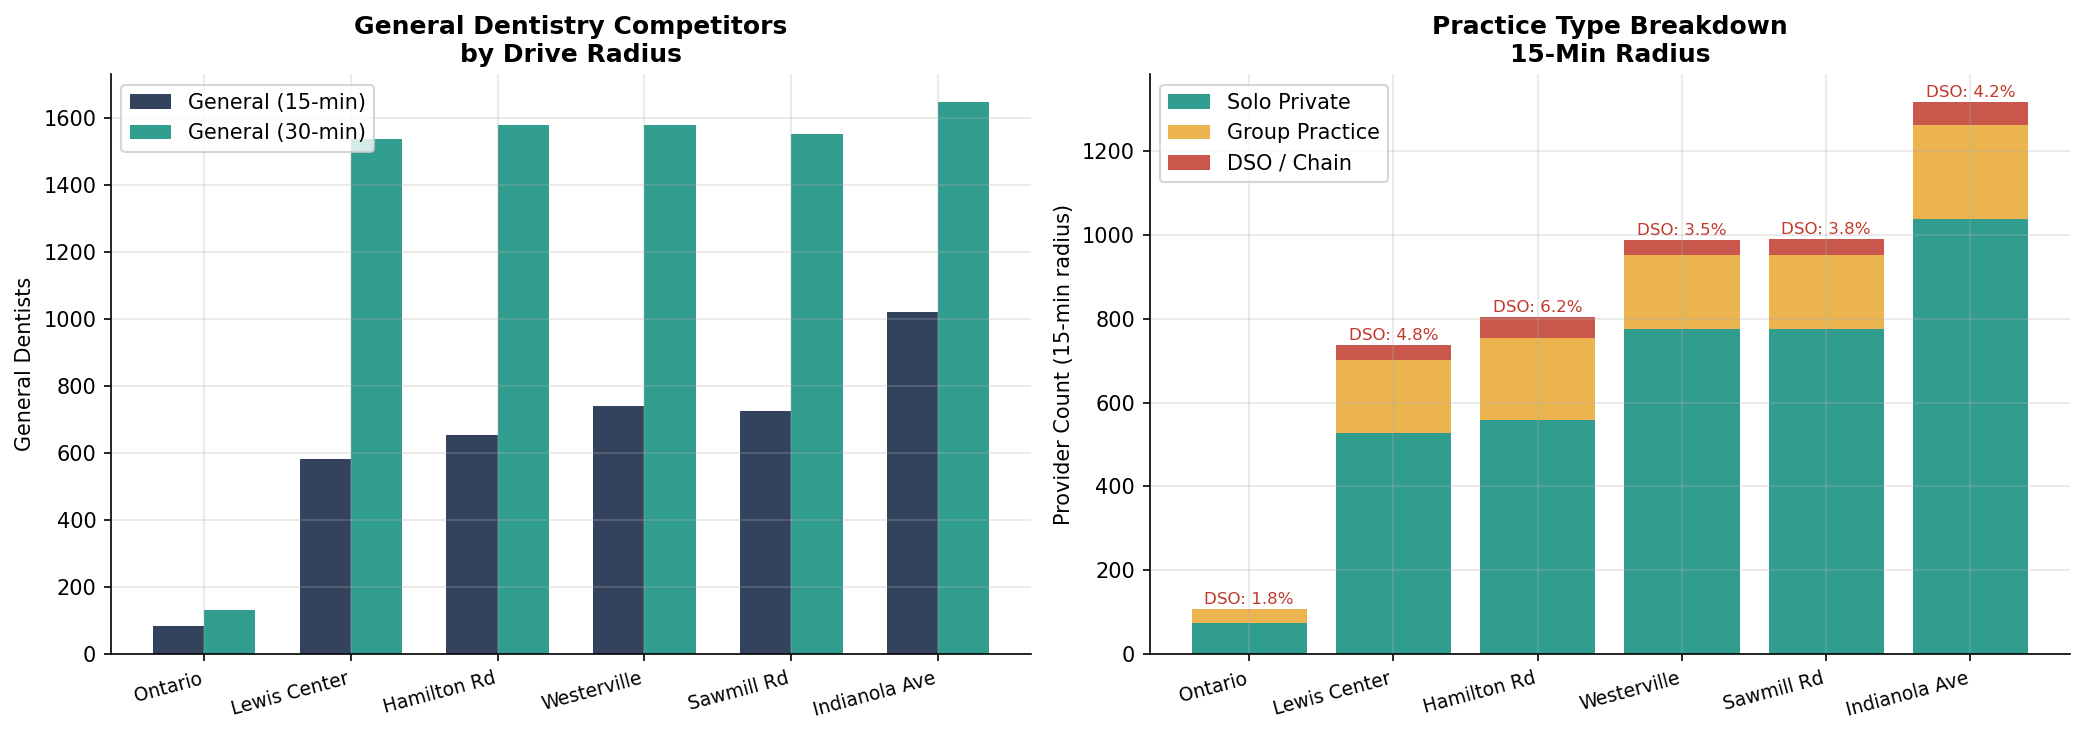

Chart 6 saved.

All charts saved to: ../charts/charts_m3


In [8]:
# CHART 1: Correlation Heatmap 
fig, ax = plt.subplots(figsize=(10, 8))
cols = corr_matrix.columns.tolist()
n    = len(cols)
data = corr_matrix.values
im   = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cols, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(cols, fontsize=9)
for i in range(n):
    for j in range(n):
        val   = data[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")
ax.set_title("Pearson Correlation Matrix — All Key Variables\n"
             "(r > 0.90 indicates variables are measuring the same construct)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "01_correlation_heatmap.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 1 saved.")

# CHART 2: Sensitivity Analysis (Rank Stability)
scenario_labels    = list(scenarios.keys())
locations_ordered  = ["Lewis Center", "Sawmill Rd", "Westerville",
                      "Hamilton Rd", "Indianola Ave", "Ontario"]
fig, ax = plt.subplots(figsize=(13, 6))
for loc in locations_ordered:
    ranks = [
        sens_df[(sens_df["location"] == loc) & (sens_df["scenario"] == s)]["rank"].values[0]
        for s in scenario_labels
    ]
    short_labels = [s.split(" ")[0] for s in scenario_labels]
    ax.plot(short_labels, ranks, marker="o", linewidth=2,
            color=COLOR_MAP[loc], label=loc, markersize=8)
ax.set_ylim(6.5, 0.5)
ax.set_ylabel("Rank (1 = best)")
ax.set_title("Ranking Stability Across 5 Weight Scenarios\n"
             "(Flat lines = robust ranking; sharp movement = sensitive to assumptions)",
             fontsize=11, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_yticks([1, 2, 3, 4, 5, 6])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "02_sensitivity_analysis.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 2 saved.")

# CHART 3: Market Gap
gap_sorted = df.sort_values("market_gap_normalized", ascending=False)
bar_colors = [COLOR_MAP[n] for n in gap_sorted["location_name"]]
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].barh(gap_sorted["location_name"], gap_sorted["residents_per_dentist"],
                    color=bar_colors, alpha=0.88)
for bar, val in zip(bars, gap_sorted["residents_per_dentist"]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                 f"{val:,.0f}", va="center", fontsize=9)
axes[0].set_xlabel("Residents per Dentist")
axes[0].set_title("Residents per Dentist\n(raw ratio)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
bars2 = axes[1].barh(gap_sorted["location_name"], gap_sorted["market_gap_normalized"],
                     color=bar_colors, alpha=0.88)
for bar, val in zip(bars2, gap_sorted["market_gap_normalized"]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("Market Gap Index (0-100)")
axes[1].set_title("Income-Weighted Market Gap\n(population × income / competitors)",
                  fontweight="bold")
plt.suptitle("Market Gap Analysis — Demand vs. Supply", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "03_market_gap.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 3 saved.")

# CHART 4: Radar Chart
radar_cols   = ["n_pop", "n_inc", "n_comp", "n_med"]
radar_labels = ["Population", "Income", "Low Competition", "Low Medicaid"]
angles       = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles      += angles[:1]
fig, axes    = plt.subplots(2, 3, figsize=(14, 9), subplot_kw=dict(polar=True))
axes         = axes.flatten()
for idx, (_, row) in enumerate(df.iterrows()):
    ax  = axes[idx]
    loc = row["location_name"]
    clr = COLOR_MAP[loc]
    values  = [row[c] for c in radar_cols] + [row[radar_cols[0]]]
    ax.plot(angles, values, color=clr, linewidth=2)
    ax.fill(angles, values, color=clr, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=6, color="grey")
    ax.set_title(f"{loc}\nScore: {row['opportunity_score']:.1f}  Rank #{int(row['rank'])}",
                 fontsize=10, fontweight="bold", color=clr, pad=12)
    ax.grid(True, alpha=0.4)
plt.suptitle("Radar Chart — Scoring Dimensions by Location\n"
             "(Larger area = better overall profile)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "04_radar_chart.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 4 saved.")

# CHART 5: Min-Max vs Z-Score Comparison 
df_sorted = df.sort_values("rank")
x, width  = np.arange(len(df)), 0.35
fig, ax   = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, df_sorted["opportunity_score"], width,
            label="Min-Max (Module 2)", color="#0F2240", alpha=0.85)
b2 = ax.bar(x + width/2, df_sorted["zscore_opportunity"], width,
            label="Z-Score (Module 3)", color="#0D8C7A", alpha=0.85)
for bar, row in zip(b1, df_sorted.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"#{int(row.rank)}", ha="center", va="bottom", fontsize=9, color="#0F2240")
for bar, row in zip(b2, df_sorted.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"#{int(row.zscore_rank)}", ha="center", va="bottom", fontsize=9, color="#0D8C7A")
ax.set_xticks(x)
ax.set_xticklabels(df_sorted["location_name"], fontsize=10)
ax.set_ylabel("Opportunity Score (0-100)")
ax.set_title("Normalization Method Comparison: Min-Max vs. Z-Score\n"
             "Rank shown above each bar — identical rankings confirm model robustness",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "05_normalization_comparison.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 5 saved.")

# CHART 6: Competition Deep-Dive 
df_comp    = df.sort_values("total_15min", ascending=True)
bar_colors = [COLOR_MAP[n] for n in df_comp["location_name"]]
x, width   = np.arange(len(df_comp)), 0.35
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x - width/2, df_comp["general_15min"], width,
            label="General (15-min)", color="#0F2240", alpha=0.85)
axes[0].bar(x + width/2, df_comp["general_30min"], width,
            label="General (30-min)", color="#0D8C7A", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_comp["location_name"], rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("General Dentists")
axes[0].set_title("General Dentistry Competitors\nby Drive Radius", fontweight="bold")
axes[0].legend()
solo  = df_comp["solo_15min"].values.astype(float)
group = df_comp["group_15min"].values.astype(float)
dso   = df_comp["dso_15min"].values.astype(float)
axes[1].bar(x, solo,  label="Solo Private",   color="#0D8C7A", alpha=0.85)
axes[1].bar(x, group, bottom=solo,            label="Group Practice", color="#E8A730", alpha=0.85)
axes[1].bar(x, dso,   bottom=solo + group,    label="DSO / Chain",    color="#C0392B", alpha=0.85)
for i, (s, g, d) in enumerate(zip(solo, group, dso)):
    total = s + g + d
    pct   = d / total * 100 if total > 0 else 0
    axes[1].text(i, total + 5, f"DSO: {pct:.1f}%",
                 ha="center", va="bottom", fontsize=8, color="#C0392B")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_comp["location_name"], rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Provider Count (15-min radius)")
axes[1].set_title("Practice Type Breakdown\n15-Min Radius", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, "06_competition_deepdive.png"), bbox_inches="tight", dpi=150)
plt.show()
plt.close()
print("Chart 6 saved.")

print("\nAll charts saved to:", CHARTS_PATH)

In [9]:
# TABLEAU EXPORTS 
# Three clean files optimized for Tableau Public mapping and dashboards.

# 1. Locations with all scores — for the primary map
tableau_locs = df[[
    "location_id", "location_name",
    "total_population", "median_income", "medicaid_pct",
    "pct_bachelor_plus", "total_15min", "total_30min",
    "general_15min", "dso_15min", "group_15min", "solo_15min",
    "opportunity_score", "rank", "market_gap_normalized",
    "residents_per_dentist",
]].copy()

locs_master = pd.read_csv(os.path.join(CLEANED_PATH, "locations_master_cleaned.csv"))
locs_master.columns = locs_master.columns.str.strip().str.lower().str.replace(" ", "_")
tableau_locs = tableau_locs.merge(
    locs_master[["location_id", "latitude", "longitude"]],
    on="location_id", how="left"
)
tableau_locs.to_csv(os.path.join(OUTPUT_PATH, "tableau_locations.csv"), index=False)
print("Saved: tableau_locations.csv")

# 2. Demographics long format — for age group charts in Tableau
age_map = {
    "pop_0_14":    "0-14",
    "pop_15_17":   "15-17",
    "pop_18_24":   "18-24",
    "pop_25_64":   "25-64",
    "pop_65_plus": "65+",
}
age_rows = []
for _, row in df.iterrows():
    total = sum(row[c] for c in age_map.keys())
    for col, label in age_map.items():
        age_rows.append({
            "location_name": row["location_name"],
            "age_group":     label,
            "population":    int(row[col]),
            "pct_of_total":  round(row[col] / total * 100, 1),
        })
tableau_demo = pd.DataFrame(age_rows)
tableau_demo.to_csv(os.path.join(OUTPUT_PATH, "tableau_demographics.csv"), index=False)
print("Saved: tableau_demographics.csv")

# 3. Competitors long format — for specialty/type breakdown in Tableau
spec_map = {
    "general_15min":      ("General Dentistry",          "15min"),
    "pediatric_15min":    ("Pediatric Dentistry",         "15min"),
    "ortho_15min":        ("Orthodontics",                "15min"),
    "oral_surgery_15min": ("Oral & Maxillofacial Surgery","15min"),
    "endo_15min":         ("Endodontics",                 "15min"),
    "perio_15min":        ("Periodontics",                "15min"),
    "prostho_15min":      ("Prosthodontics",              "15min"),
    "general_30min":      ("General Dentistry",           "30min"),
    "pediatric_30min":    ("Pediatric Dentistry",         "30min"),
    "ortho_30min":        ("Orthodontics",                "30min"),
    "oral_surgery_30min": ("Oral & Maxillofacial Surgery","30min"),
    "endo_30min":         ("Endodontics",                 "30min"),
    "perio_30min":        ("Periodontics",                "30min"),
    "prostho_30min":      ("Prosthodontics",              "30min"),
}
comp_rows = []
for _, row in df.iterrows():
    for col, (specialty, radius) in spec_map.items():
        if col in df.columns:
            comp_rows.append({
                "location_name": row["location_name"],
                "specialty":     specialty,
                "radius":        radius,
                "count":         int(row[col]),
            })
tableau_comp = pd.DataFrame(comp_rows)
tableau_comp.to_csv(os.path.join(OUTPUT_PATH, "tableau_competitors.csv"), index=False)
print("Saved: tableau_competitors.csv")

Saved: tableau_locations.csv
Saved: tableau_demographics.csv
Saved: tableau_competitors.csv


In [10]:
# SUMMARY 
print("=" * 65)
print("MODULE 3 — SUMMARY OUTPUT FOR REPORT")
print("=" * 65)

print("\n--- CORRELATION HIGHLIGHTS ---")
print(f"  Income vs Education r:          {r_inc_edu:.2f} (>0.90 = redundant)")
print(f"  Competitors 15min vs 30min r:   {r_15_30:.2f}")
print(f"  Total vs General dentists r:    {r_tot_gen:.2f}")

print("\n--- SENSITIVITY ANALYSIS SUMMARY ---")
print(pivot_rank.to_string())
print(f"\nLocations ranking #1 by scenario: {top1_counts.to_dict()}")

print("\n--- MARKET GAP INDEX (ranked) ---")
for _, row in df.sort_values("market_gap_normalized", ascending=False).iterrows():
    print(f"  {row['location_name']:<16}  "
          f"Gap Index={row['market_gap_normalized']:.1f}  "
          f"Residents/Dentist={row['residents_per_dentist']:,.0f}")

print("\n--- NORMALIZATION METHOD COMPARISON ---")
for _, row in df.sort_values("rank").iterrows():
    match = "✓ Same" if row["rank"] == row["zscore_rank"] else f"✗ Diff (Z=#{int(row['zscore_rank'])})"
    print(f"  {row['location_name']:<16}  MinMax #{int(row['rank'])}  "
          f"ZScore #{int(row['zscore_rank'])}  {match}")

print("\n--- TABLEAU FILES SAVED ---")
print(f"  {os.path.join(OUTPUT_PATH, 'tableau_locations.csv')}")
print(f"  {os.path.join(OUTPUT_PATH, 'tableau_demographics.csv')}")
print(f"  {os.path.join(OUTPUT_PATH, 'tableau_competitors.csv')}")
print(f"\nCharts saved to: {CHARTS_PATH}/ (6 PNG files)")

MODULE 3 — SUMMARY OUTPUT FOR REPORT

--- CORRELATION HIGHLIGHTS ---
  Income vs Education r:          0.89 (>0.90 = redundant)
  Competitors 15min vs 30min r:   0.89
  Total vs General dentists r:    1.00

--- SENSITIVITY ANALYSIS SUMMARY ---
scenario       Base (30/30/25/15)  Competition+ (25/25/40/10)  Equal (25/25/25/25)  Income+ (20/45/25/10)  Population+ (45/25/20/10)
location                                                                                                                            
Hamilton Rd                     4                           4                    4                      4                          4
Indianola Ave                   5                           5                    5                      5                          5
Lewis Center                    1                           1                    2                      1                          1
Ontario                         6                           6                    6         